In [4]:
import pandas as pd

df = pd.read_csv("emails.csv")
print(df.head())

                                              text label
0    Let's schedule a meeting for tomorrow at 10am  work
1  Please find the attached report for your review  work
2         Can you update me on the project status?  work
3         We need to finalize the budget by Friday  work
4                    Reminder: team standup at 9am  work


In [5]:
import re

def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove punctuation & numbers
    return text

df["clean_text"] = df["text"].apply(clean_text)

df.head()

,text,label,clean_text
0,Let's schedule a meeting for tomorrow at 10am,work,lets schedule a meeting for tomorrow at am
1,Please find the attached report for your review,work,please find the attached report for your review
2,Can you update me on the project status?,work,can you update me on the project status
3,We need to finalize the budget by Friday,work,we need to finalize the budget by friday
4,Reminder: team standup at 9am,work,reminder team standup at am


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["clean_text"])
y = df["label"]

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [9]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7307692307692307


In [10]:
sample = ["Let's schedule a meeting tomorrow"]

sample_clean = [clean_text(s) for s in sample]
sample_vec = vectorizer.transform(sample_clean)

prediction = model.predict(sample_vec)

print("Prediction:", prediction)

Prediction: ['work']


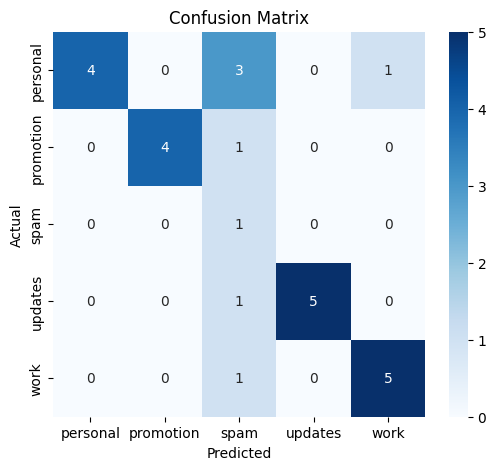

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [12]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

    personal       1.00      0.50      0.67         8
   promotion       1.00      0.80      0.89         5
        spam       0.14      1.00      0.25         1
     updates       1.00      0.83      0.91         6
        work       0.83      0.83      0.83         6

    accuracy                           0.73        26
   macro avg       0.80      0.79      0.71        26
weighted avg       0.93      0.73      0.79        26

